# 웹 로그 데이터 수집 및 탐색적 분석 (EDA)
**7주차 2교시 — CSIC 2010 데이터셋으로 공격 패턴 직접 확인하기**

- `csic_database.csv` (61,065건) → 라벨 비율 유지하며 **1만 건 샘플링**
- 정상 vs 공격의 차이를 시각화하며 1교시에 배운 키워드를 실제 데이터에서 확인

> **[Setup] 셀을 반드시 먼저 실행하세요 (Shift+Enter)**

In [8]:
# %% [Setup] 패키지 import 및 데이터 로드 + 1만 건 샘플링
import os
import re
import pandas as pd
import plotly.express as px
from urllib.parse import unquote

try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()

# csic_database.csv 로드 (원본 61,065건)
raw = pd.read_csv(os.path.join(SCRIPT_DIR, "data", "archive", "csic_database.csv"))

# 컬럼 정규화 (PPT 9페이지 download_csic2010.py 로직)
df = pd.DataFrame()
df["label"]          = raw.iloc[:, 0]
df["method"]         = raw["Method"]
df["body"]           = raw["content"].fillna("")
df["classification"] = raw["classification"]

def clean_url(s):
    s = re.sub(r"^https?://[^/]+", "", str(s))
    s = re.sub(r"\s+HTTP/[\d.]+\s*$", "", s)
    return s.strip()

df["url"] = raw["URL"].apply(clean_url)

# 라벨 비율 유지하며 1만 건 샘플링 (random_state=42 고정)
normal    = df[df["label"] == "Normal"].sample(n=5895, random_state=42)
anomalous = df[df["label"] == "Anomalous"].sample(n=4105, random_state=42)
df = pd.concat([normal, anomalous]).sample(frac=1, random_state=42).reset_index(drop=True)

# 분석용 파생 컬럼
df["url_decoded"]  = df["url"].apply(lambda x: unquote(str(x), encoding="latin-1"))
df["body_decoded"] = df["body"].apply(lambda x: unquote(str(x), encoding="latin-1"))
df["full_text"]    = df["url_decoded"] + " " + df["body_decoded"]
df["url_length"]   = df["url_decoded"].str.len()
df["body_length"]  = df["body_decoded"].str.len()
df["is_attack"]    = (df["label"] == "Anomalous").astype(int)

print(f"데이터 로드: {len(df):,}건  (정상 {(df['label']=='Normal').sum():,} / 공격 {(df['label']=='Anomalous').sum():,})")
df.head()

데이터 로드: 10,000건  (정상 5,895 / 공격 4,105)


,label,method,body,classification,url,url_decoded,body_decoded,full_text,url_length,body_length,is_attack
0,Anomalous,POST,idA=2,1,/tienda1/publico/caracteristicas.jsp,/tienda1/publico/caracteristicas.jsp,idA=2,/tienda1/publico/caracteristicas.jsp idA=2,36,5,1
1,Normal,GET,,0,/tienda1/miembros/imagenes/ogono.jpg,/tienda1/miembros/imagenes/ogono.jpg,,/tienda1/miembros/imagenes/ogono.jpg,36,0,0
2,Normal,POST,B2=Vaciar+carrito,0,/tienda1/publico/vaciar.jsp,/tienda1/publico/vaciar.jsp,B2=Vaciar+carrito,/tienda1/publico/vaciar.jsp B2=Vaciar+carrito,27,17,0
3,Normal,GET,,0,/tienda1/index.jsp,/tienda1/index.jsp,,/tienda1/index.jsp,18,0,0
4,Normal,GET,,0,/tienda1/global/titulo.jsp,/tienda1/global/titulo.jsp,,/tienda1/global/titulo.jsp,26,0,0


## 실습 3 — 데이터 로드 및 기본 탐색

In [9]:
# %% [1] 라벨 분포 확인 ★
# 정상 59% : 공격 41% — 불균형 데이터
# ★ 정확도의 함정: 모두 정상 예측 시 정확도 59%지만 공격을 단 1건도 못 잡음
# ★ 보안에서는 미탐(FN)이 더 위험 → 재현율(Recall)을 중시
print(df["label"].value_counts())
print()

label_counts = df["label"].value_counts()
label_ratio  = df["label"].value_counts(normalize=True) * 100

print(f"  {'라벨':<12s} | {'건수':>8s} | {'비율':>6s} | 시각화")
print(f"  {'─'*12}-+-{'─'*8}-+-{'─'*6}-+-{'─'*30}")
for label in label_counts.index:
    bar = "█" * int(label_ratio[label] / 2)
    print(f"  {label:<12s} | {label_counts[label]:>8,} | {label_ratio[label]:>5.1f}% | {bar}")

label
Normal       5895
Anomalous    4105
Name: count, dtype: int64

  라벨           |       건수 |     비율 | 시각화
  ────────────-+-────────-+-──────-+-──────────────────────────────
  Normal       |    5,895 |  59.0% | █████████████████████████████
  Anomalous    |    4,105 |  41.0% | ████████████████████


In [10]:
# %% [2] HTTP 메서드 분포
print(df["method"].value_counts())

# 정상 요청 1건 확인
normal = df[df["label"] == "Normal"].iloc[0]
print("\n=== 정상 요청 ===")
print(f"메서드: {normal['method']}")
print(f"URL:    {normal['url']}")

# 공격 요청 1건 확인
attack = df[df["label"] == "Anomalous"].iloc[0]
print("\n=== 공격 요청 ===")
print(f"메서드: {attack['method']}")
print(f"URL:    {attack['url']}")
if attack["body"]:
    print(f"Body:   {attack['body']}")
print("\n>>> 1교시 키워드를 직접 찾아보세요! → ' , OR , 1=1 , <script> , ../")

method
GET     6984
POST    2945
PUT       71
Name: count, dtype: int64

=== 정상 요청 ===
메서드: GET
URL:    /tienda1/miembros/imagenes/ogono.jpg

=== 공격 요청 ===
메서드: POST
URL:    /tienda1/publico/caracteristicas.jsp
Body:   idA=2

>>> 1교시 키워드를 직접 찾아보세요! → ' , OR , 1=1 , <script> , ../


## 실습 4-A — EDA 시각화 (Plotly)

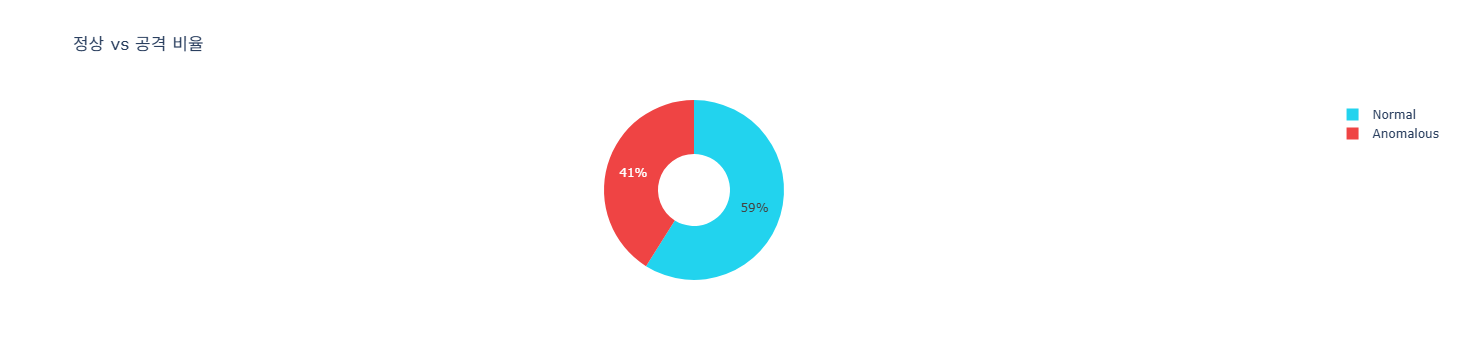

In [11]:
# %% [3] 정상 vs 공격 비율 (파이 차트)
fig = px.pie(
    values=df["label"].value_counts().values,
    names=df["label"].value_counts().index,
    title="정상 vs 공격 비율",
    color_discrete_sequence=["#22d3ee", "#ef4444"],
    hole=0.4,
)
fig.show()

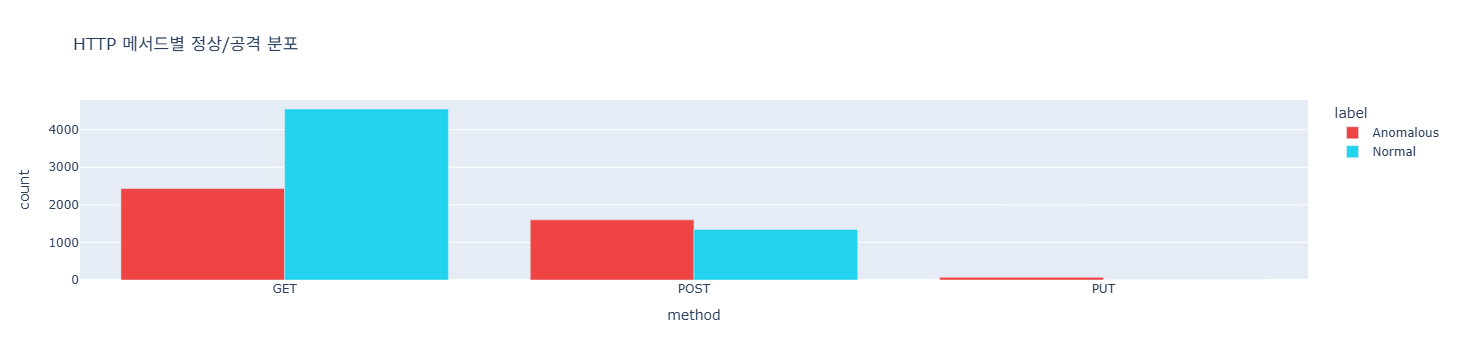

,공격 건수,전체 건수,공격 비율(%)
method,,,
GET,2434,6984,34.9
POST,1600,2945,54.3
PUT,71,71,100.0


In [12]:
# %% [4] HTTP 메서드별 정상/공격 분포 (그룹 막대)
cross = pd.crosstab(df["method"], df["label"]).reset_index()
cross_melted = cross.melt(id_vars="method", var_name="label", value_name="count")

fig = px.bar(
    cross_melted,
    x="method", y="count", color="label",
    title="HTTP 메서드별 정상/공격 분포",
    barmode="group",
    color_discrete_map={"Normal": "#22d3ee", "Anomalous": "#ef4444"},
)
fig.show()

method_attack = df.groupby("method")["is_attack"].agg(["sum", "count"])
method_attack["공격 비율(%)"] = (method_attack["sum"] / method_attack["count"] * 100).round(1)
method_attack.columns = ["공격 건수", "전체 건수", "공격 비율(%)"]
method_attack

정상 URL 평균: 50
공격 URL 평균: 73


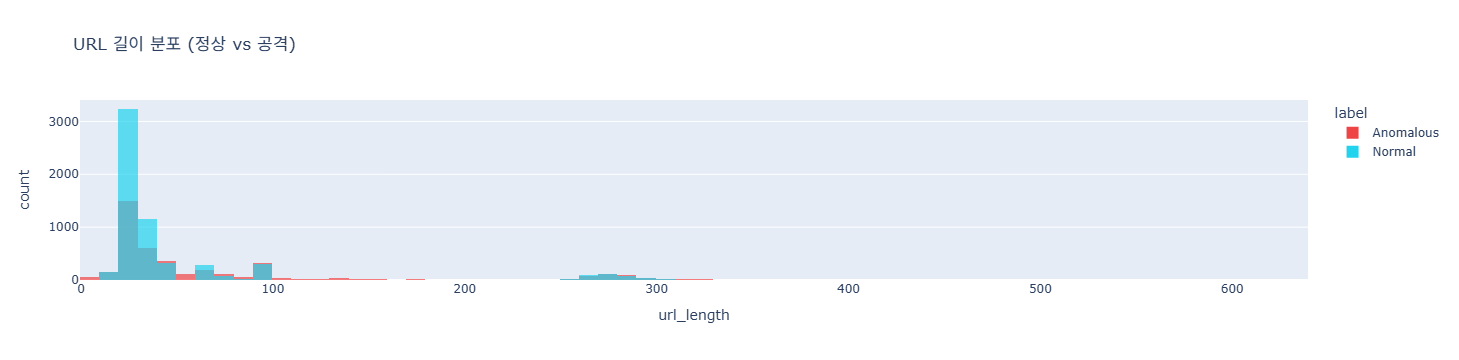

In [13]:
# %% [5] URL 길이 분포 히스토그램 (정상 vs 공격)
# 관찰: 공격 요청의 URL이 평균적으로 더 길다 (SQL/XSS 코드 삽입 때문)
print(f"정상 URL 평균: {df[df['label']=='Normal']['url_length'].mean():.0f}")
print(f"공격 URL 평균: {df[df['label']=='Anomalous']['url_length'].mean():.0f}")

fig = px.histogram(
    df,
    x="url_length", color="label",
    title="URL 길이 분포 (정상 vs 공격)",
    barmode="overlay", opacity=0.7, nbins=100,
    color_discrete_map={"Normal": "#22d3ee", "Anomalous": "#ef4444"},
)
fig.show()

POST 요청 수: 2,945건


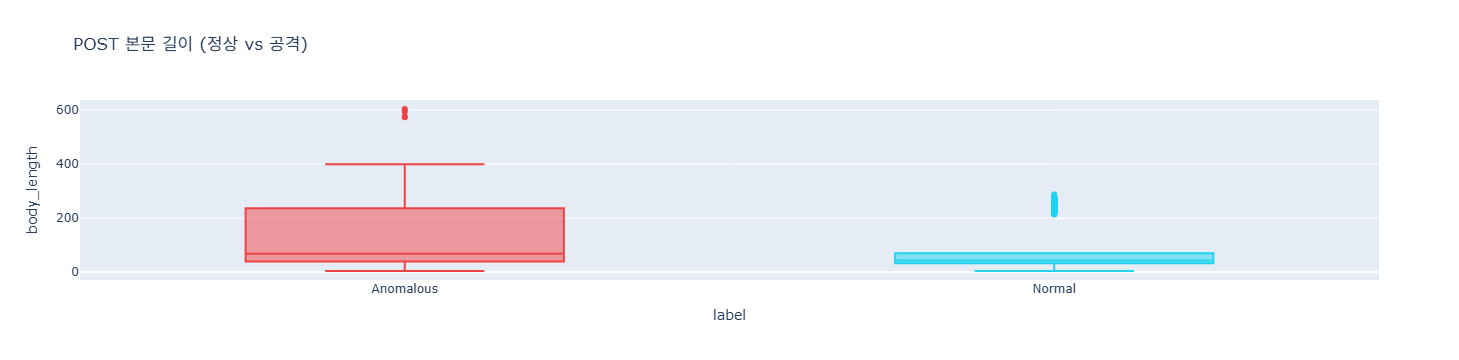

In [14]:
# %% [6] POST 본문 길이 Box Plot
# POST 본문은 로그인/검색/주문 입력값 → 공격이 집중되는 곳!
post_df = df[df["method"] == "POST"].copy()
print(f"POST 요청 수: {len(post_df):,}건")

fig = px.box(
    post_df,
    x="label", y="body_length",
    title="POST 본문 길이 (정상 vs 공격)",
    color="label",
    color_discrete_map={"Normal": "#22d3ee", "Anomalous": "#ef4444"},
)
fig.update_layout(showlegend=False)
fig.show()

## 실습 4-B — 공격 키워드 / URL 인코딩 / 경로 분석

In [15]:
# %% [7] 공격 키워드 빈도 분석 ★★
# case=False: 공격자가 SeLeCt처럼 대소문자 섞어 필터 우회 시도 → 대소문자 무시로 대응
attack_keywords = {
    "SQL Injection":    ["'", "OR", "UNION", "SELECT", "DROP", "--", "1=1"],
    "XSS":              ["<script", "alert(", "onerror", "<iframe", "<img", "javascript:"],
    "Path Traversal":   ["../", "%2e%2e", "/etc/passwd", "/etc/shadow"],
    "Command Injection":["%;", "|", "&&", "/bin/", "cat ", "rm "],
}

for category, keywords in attack_keywords.items():
    count = sum(
        df["full_text"].str.contains(re.escape(kw), case=False, na=False).sum()
        for kw in keywords
    )
    print(f"{category}: {count}건에서 관련 키워드 발견")

SQL Injection: 3920건에서 관련 키워드 발견
XSS: 232건에서 관련 키워드 발견
Path Traversal: 33건에서 관련 키워드 발견
Command Injection: 34건에서 관련 키워드 발견


In [16]:
# %% [8] URL 인코딩 패턴 분석
# %27=' , %3C=< , %2F=/ , %0d=%0a=CRLF → 공격 요청에 집중됨
encoded_patterns = ["%27", "%3C", "%3E", "%2F", "%0d", "%0a", "%00"]

print(f"  {'패턴':<6s}  의미       정상   공격")
print("  " + "─" * 35)
meanings = {"'", "<", ">", "/", "\\r", "\\n", "NULL"}
for p, m in zip(encoded_patterns, meanings):
    n = df[df["label"] == "Normal"]["url"].str.contains(p, case=False, na=False).sum()
    a = df[df["label"] == "Anomalous"]["url"].str.contains(p, case=False, na=False).sum()
    print(f"  {p:<6s}  {m:<8s}   {n:>4}   {a:>4}")

  패턴      의미       정상   공격
  ───────────────────────────────────
  %27     <             6    240
  %3C     >             0     94
  %3E     NULL          0     94
  %2F     /           125    394
  %0d     \n            0      0
  %0a     \r            0      0
  %00     '             0      0


In [17]:
# %% [9] 요청 경로 분석 — 공격이 집중되는 경로 확인
df["path"] = df["url"].str.split("?").str[0]
df["path_depth"] = df["path"].str.count("/")

print("=== 전체 Top 10 경로 ===")
print(df["path"].value_counts().head(10))

print("\n=== 공격 요청 Top 10 경로 ===")
print(df[df["label"] == "Anomalous"]["path"].value_counts().head(10))

=== 전체 Top 10 경로 ===
path
/tienda1/publico/registro.jsp            842
/tienda1/miembros/editar.jsp             800
/tienda1/publico/pagar.jsp               791
/tienda1/publico/autenticar.jsp          782
/tienda1/publico/anadir.jsp              767
/tienda1/publico/vaciar.jsp              676
/tienda1/publico/entrar.jsp              636
/tienda1/publico/caracteristicas.jsp     618
/tienda1/miembros/imagenes/zarauz.jpg    178
/tienda1/miembros/fotos.jsp              177
Name: count, dtype: int64

=== 공격 요청 Top 10 경로 ===
path
/tienda1/publico/registro.jsp           490
/tienda1/publico/pagar.jsp              464
/tienda1/miembros/editar.jsp            460
/tienda1/publico/autenticar.jsp         447
/tienda1/publico/anadir.jsp             444
/tienda1/publico/vaciar.jsp             328
/tienda1/publico/caracteristicas.jsp    303
/tienda1/publico/entrar.jsp             269
/1.1                                     39
/4861362529278789730                     11
Name: count, dtype: int64


In [18]:
# %% [10] 전체 10,000건 데이터 출력
pd.set_option("display.max_rows", 10000)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

print(f"전체 {len(df):,}건")
df[["label", "method", "url", "body", "url_length", "body_length"]]

전체 10,000건


,label,method,url,body,url_length,body_length
0,Anomalous,POST,/tienda1/publico/caracteristicas.jsp,idA=2,36,5
1,Normal,GET,/tienda1/miembros/imagenes/ogono.jpg,,36,0
2,Normal,POST,/tienda1/publico/vaciar.jsp,B2=Vaciar+carrito,27,17
3,Normal,GET,/tienda1/index.jsp,,18,0
4,Normal,GET,/tienda1/global/titulo.jsp,,26,0
5,Anomalous,POST,/tienda1/publico/caracteristicas.jsp,id=%27%2C%270%27%2C%270%27%2C%270%27%2C%270%27%29%3Bwaitfor+delay+%270%3A0%3...,36,47
6,Normal,GET,/tienda1/imagenes/1.gif,,23,0
7,Normal,POST,/tienda1/publico/pagar.jsp,modo=insertar&precio=1459&B1=Pasar+por+caja,26,43
8,Anomalous,GET,/tienda1/imagenes/logo.gif/,,27,0
9,Normal,GET,/tienda1/publico/pagar.jsp?modo=insertar&precio=1437&B1=Pasar+por+caja,,70,0


In [19]:
# %% [마무리] 데이터 훑어보기 챌린지
# 무작위 5개 요청 — 공격이라고 확신하는 것을 찾고 근거 한 줄 작성!
sample = df.sample(5, random_state=42)
for i, row in sample.iterrows():
    icon = "✅" if row["label"] == "Normal" else "🚨"
    print(f"{icon} [{row['label']:<10s}] {row['method']:<5s} {row['url'][:120]}")
    if row["body"]:
        print(f"      BODY: {row['body'][:100]}")
    print()

print(">>> ' , <script> , ../ , UNION 을 눈으로 찾아보세요!")

🚨 [Anomalous ] GET   /tienda1/miembros/editar.jsp?modo=registro&loginA=lieure&password=rEbatible&nombre=Tarciano&apellidos=Villalta+Tapasco&e

🚨 [Anomalous ] GET   /admin/login.do

✅ [Normal    ] POST  /tienda1/publico/entrar.jsp
      BODY: errorMsg=Credenciales+incorrectas

✅ [Normal    ] GET   /tienda1/publico/productos.jsp

✅ [Normal    ] GET   /tienda1/publico/anadir.jsp?id=1&nombre=Jam%F3n+Ib%E9rico&precio=100&cantidad=22&B1=A%F1adir+al+carrito

>>> ' , <script> , ../ , UNION 을 눈으로 찾아보세요!
